# Notebook 2: Análise de Despesas (Analytics & Insights)

Com a estrutura do nosso Lakehouse validada e o comportamento macro dos dados compreendido no Notebook 1, esta segunda etapa foca em responder às hipóteses de negócio, explorando a relação entre o orçamento público e o cenário político-temporal.

## Seção 1: Ciclos Políticos e o Orçamento

Nesta seção, exploraremos como os atributos políticos de contexto (`fl_ano_eleitoral`, `tipo_eleicao`, `fl_ano_pre_eleitoral`, `fl_ano_pos_eleitoral` e `governo`) influenciam a liberação e execução dos gastos públicos nos pacotes monitorados.

### Hipótese 1: O gasto público aumenta em anos de eleição?
**Objetivo:** Cruzar a variável lógica `fl_ano_eleitoral` com o volume de despesas de cada pacote para identificar visualmente se existe um padrão de elevação ou alteração na média de gastos em períodos eleitorais. 

*Nota: Desconsideramos o ano de 2026 nesta análise por se tratar de um período ainda em curso com dados parciais.*

In [2]:
%pip install duckdb


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

# Conectando ao Lakehouse
con = duckdb.connect(
    "../duckdb/lakehouse.duckdb",
    read_only=True
)
print("Conexão estabelecida com sucesso!")

Conexão estabelecida com sucesso!


In [4]:
df_eleicao = con.sql("""
    SELECT 
        pacote,
        fl_ano_eleitoral,
        SUM(valor_pago) as total_pago
    FROM ouro.despesas_por_orgao
    WHERE ano < 2026
    GROUP BY pacote, fl_ano_eleitoral
    ORDER BY pacote, fl_ano_eleitoral
""").df()

print("--- Volume Total de Gastos Acumulados (2014 - 2025) ---")
display(df_eleicao)

--- Volume Total de Gastos Acumulados (2014 - 2025) ---


,pacote,fl_ano_eleitoral,total_pago
0,coordenacao_politica,False,1.106234e+13
1,coordenacao_politica,True,1.042489e+13
2,infraestrutura,False,5.666348e+11
3,infraestrutura,True,5.250768e+11
4,nucleo_eleitoral,False,6.664843e+12
5,nucleo_eleitoral,True,6.353602e+12


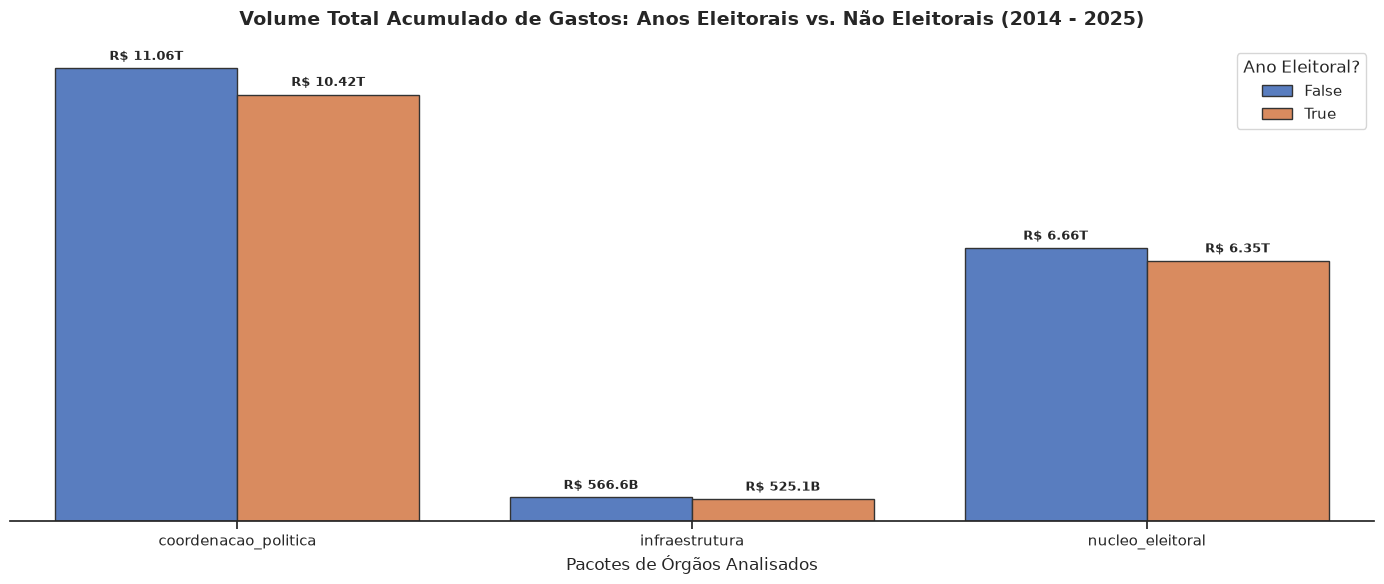

In [5]:
sns.set_theme(style="ticks")
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=df_eleicao, 
    x='pacote', 
    y='total_pago', 
    hue='fl_ano_eleitoral', 
    palette='muted',
    edgecolor='0.2'
)

plt.title('Volume Total Acumulado de Gastos: Anos Eleitorais vs. Não Eleitorais (2014 - 2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Pacotes de Órgãos Analisados', fontsize=12)

plt.ylabel('')
ax.set_yticklabels([])
ax.get_yaxis().set_visible(False)

plt.legend(title='Ano Eleitoral?', loc='upper right')

for container in ax.containers:
    labels = []
    for v in container:
        height = v.get_height()
        if height >= 1e12:
            labels.append(f'R$ {height/1e12:.2f}T')
        elif height >= 1e9:
            labels.append(f'R$ {height/1e9:.1f}B')
        else:
            labels.append(f'R$ {height/1e6:.0f}M')
    ax.bar_label(container, labels=labels, label_type='edge', fontsize=9, fontweight='bold', padding=4)

sns.despine(left=True)
plt.tight_layout()
plt.show()

### 💡 Hipótese 2: O comportamento orçamentário muda dependendo do tipo de eleição?
**Objetivo:** Avaliar se a liberação de recursos se comporta de maneira diferente quando estamos em anos de eleições Federais (Presidente e Deputados) comparado a anos de eleições Municipais (Prefeitos e Vereadores). Isso nos ajudará a entender se o ciclo político atinge os pacotes de forma centralizada ou descentralizada.

In [6]:
# Soma de gastos por Tipo de Eleição e Pacote (removendo nulos e ano de 2026)
df_tipo_eleicao = con.sql("""
    SELECT 
        pacote,
        tipo_eleicao,
        SUM(valor_pago) as total_pago
    FROM ouro.despesas_por_orgao
    WHERE tipo_eleicao IS NOT NULL 
      AND tipo_eleicao != 'Não aplicável'
      AND ano < 2026
    GROUP BY pacote, tipo_eleicao
    ORDER BY pacote, total_pago DESC
""").df()

print("--- Gastos por Tipo de Eleição ---")
display(df_tipo_eleicao)

--- Gastos por Tipo de Eleição ---


,pacote,tipo_eleicao,total_pago
0,coordenacao_politica,municipal,5.622548e+12
1,coordenacao_politica,geral,4.802339e+12
2,infraestrutura,geral,2.741818e+11
3,infraestrutura,municipal,2.508950e+11
4,nucleo_eleitoral,municipal,3.607910e+12
5,nucleo_eleitoral,geral,2.745692e+12


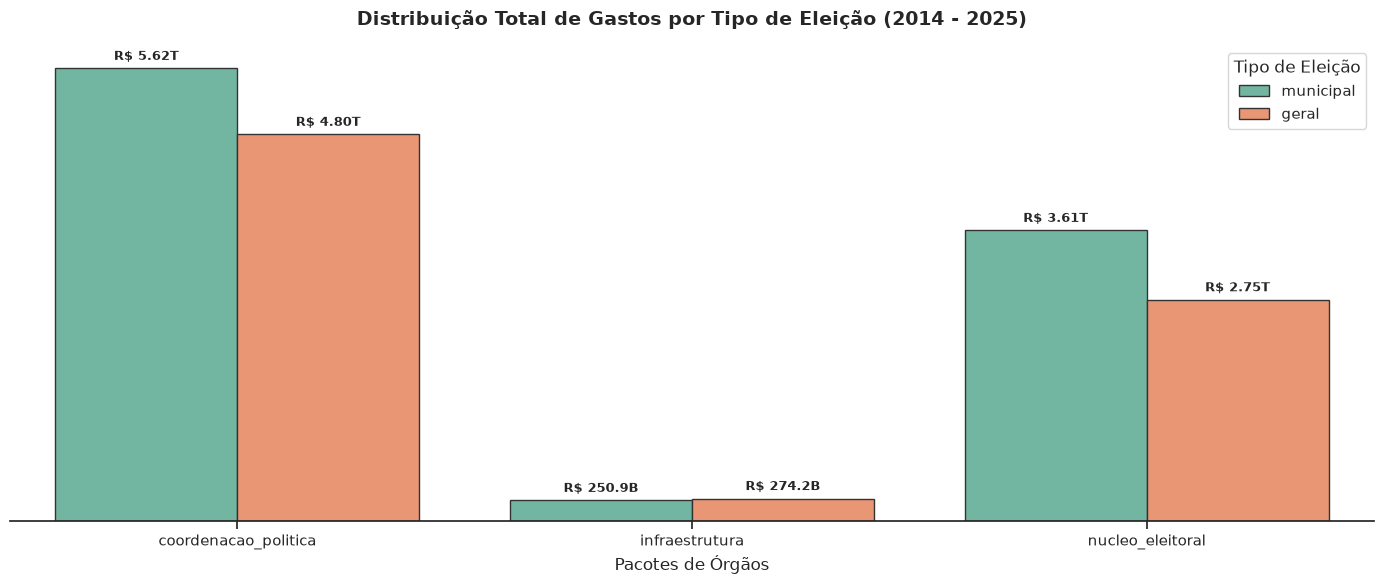

In [7]:
plt.figure(figsize=(14, 6))

# Criação do gráfico de barras segmentado
ax2 = sns.barplot(
    data=df_tipo_eleicao, 
    x='pacote', 
    y='total_pago', 
    hue='tipo_eleicao', 
    palette='Set2',
    edgecolor='0.2'
)

# Customização de títulos e eixos
plt.title('Distribuição Total de Gastos por Tipo de Eleição (2014 - 2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Pacotes de Órgãos', fontsize=12)

plt.ylabel('')
ax2.set_yticklabels([])
ax2.get_yaxis().set_visible(False)

plt.legend(title='Tipo de Eleição', loc='upper right')

# Adicionando rótulos de dados
for container in ax2.containers:
    labels = []
    for v in container:
        height = v.get_height()
        if height >= 1e12:
            labels.append(f'R$ {height/1e12:.2f}T')
        elif height >= 1e9:
            labels.append(f'R$ {height/1e9:.1f}B')
        else:
            labels.append(f'R$ {height/1e6:.0f}M')
    ax2.bar_label(container, labels=labels, label_type='edge', fontsize=9, fontweight='bold', padding=4)

sns.despine(left=True)
plt.tight_layout()
plt.show()

---

### Hipótese 3: Transições de Governo alteram as prioridades dos pacotes?
**Objetivo:** Analisar se a mudança de gestão no Poder Executivo (coluna `governo`) redefine quais pacotes recebem maior aporte financeiro. Essa análise é crucial para identificar se pacotes como `infraestrutura` ou `nucleo_eleitoral` sofrem guinadas dependendo da agenda política de cada governo.

In [8]:
# Total pago acumulado por Governo e por Pacote
df_governo = con.sql("""
    SELECT 
        governo,
        pacote,
        SUM(valor_pago) as total_pago
    FROM ouro.despesas_por_orgao
    WHERE ano < 2026
    GROUP BY governo, pacote
    ORDER BY governo, total_pago DESC
""").df()

print("--- Distribuição do Orçamento por Gestão de Governo ---")
display(df_governo)

--- Distribuição do Orçamento por Gestão de Governo ---


,governo,pacote,total_pago
0,Bolsonaro,coordenacao_politica,7.626139e+12
1,Bolsonaro,nucleo_eleitoral,4.525876e+12
2,Bolsonaro,infraestrutura,3.921614e+11
3,Dilma 1,coordenacao_politica,1.177664e+12
4,Dilma 1,nucleo_eleitoral,6.459961e+11
5,Dilma 1,infraestrutura,7.486689e+10
6,Dilma 2,coordenacao_politica,1.207503e+12
7,Dilma 2,nucleo_eleitoral,7.013839e+11
8,Dilma 2,infraestrutura,5.970516e+10
9,Lula 3,coordenacao_politica,7.534144e+12


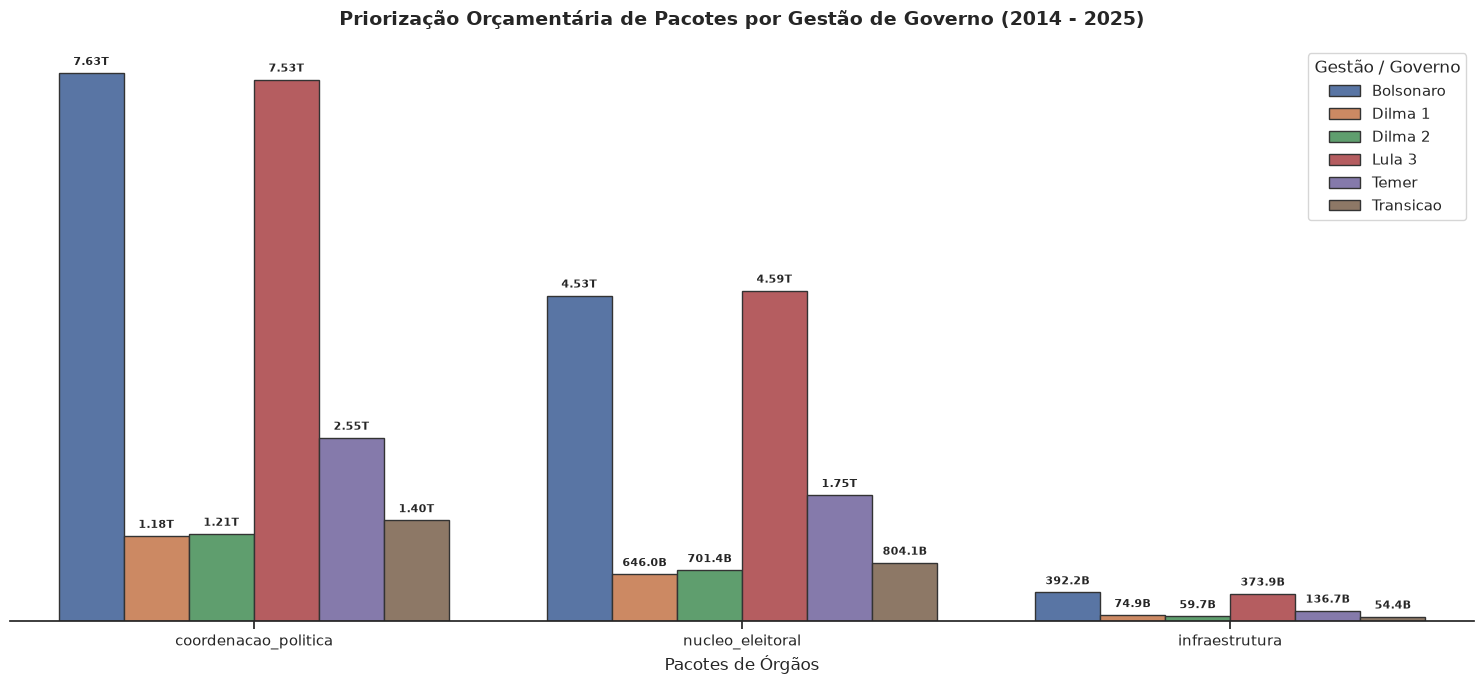

In [9]:
plt.figure(figsize=(15, 7))

# Criando o gráfico de barras comparando os governos lado a lado para cada pacote
ax3 = sns.barplot(
    data=df_governo, 
    x='pacote', 
    y='total_pago', 
    hue='governo', 
    palette='deep',
    edgecolor='0.2'
)

# Customização de títulos e eixos
plt.title('Priorização Orçamentária de Pacotes por Gestão de Governo (2014 - 2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Pacotes de Órgãos', fontsize=12)

# --- CORREÇÃO DO EIXO Y (Remove a escala 1e12 e limpa o visual) ---
plt.ylabel('')
ax3.set_yticklabels([])
ax3.get_yaxis().set_visible(False)

# --- CORREÇÃO DA LEGENDA (Puxa automaticamente os blocos coloridos da paleta 'deep') ---
plt.legend(title='Gestão / Governo', loc='upper right')

# Adicionando os rótulos de dados
for container in ax3.containers:
    labels = []
    for v in container:
        height = v.get_height()
        if height >= 1e12:
            labels.append(f'{height/1e12:.2f}T')
        elif height >= 1e9:
            labels.append(f'{height/1e9:.1f}B')
        else:
            labels.append(f'{height/1e6:.0f}M')
    ax3.bar_label(container, labels=labels, label_type='edge', fontsize=8, fontweight='bold', padding=4)

# Remoção estrita das bordas desnecessárias
sns.despine(left=True)
plt.tight_layout()
plt.show()

---

### 💡 Hipótese 4: O aumento dos gastos ocorre antes da eleição?
**Objetivo:** Avaliar se os gastos públicos apresentam maior crescimento em anos pré-eleitorais do que nos próprios anos eleitorais, conforme sugerido pela teoria dos Ciclos Políticos Orçamentários.

In [17]:
con.sql("""
SELECT
    ano,
    fl_ano_eleitoral,
    fl_ano_pre_eleitoral,
    fl_ano_pos_eleitoral
FROM ouro.despesas_por_orgao
GROUP BY ALL
ORDER BY ano
""").df()

,ano,fl_ano_eleitoral,fl_ano_pre_eleitoral,fl_ano_pos_eleitoral
0,2014,True,<NA>,False
1,2015,False,True,True
2,2016,True,False,False
3,2016,True,False,<NA>
4,2017,False,True,True
5,2017,False,True,<NA>
6,2018,True,<NA>,False
7,2018,True,False,False
8,2018,True,False,<NA>
9,2019,False,True,<NA>


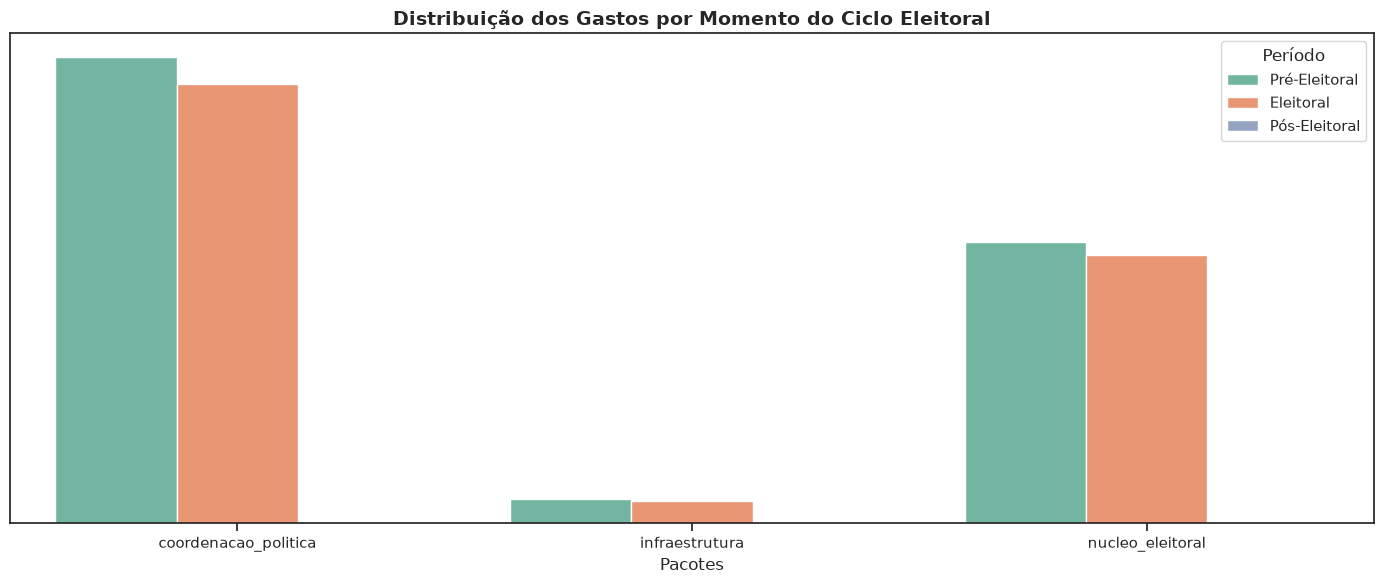

In [11]:
plt.figure(figsize=(14,6))

ax = sns.barplot(
    data=df_pre_pos,
    x='pacote',
    y='total_pago',
    hue='periodo',
    palette='Set2'
)

plt.title(
    'Distribuição dos Gastos por Momento do Ciclo Eleitoral',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Pacotes')
plt.ylabel('')
ax.get_yaxis().set_visible(False)

plt.legend(title='Período')
plt.tight_layout()
plt.show()

---

### 💡 Hipótese 5: Existe retração dos gastos após eleições?
**Objetivo:** Verificar se ocorre redução dos gastos públicos em anos pós-eleitorais, indicando possível ajuste fiscal após o período eleitoral.

In [15]:
df_yoy = con.sql("""
SELECT
    pacote,
    CAST(fl_ano_eleitoral AS VARCHAR) AS fl_ano_eleitoral,
    AVG(variacao_yoy_pct) AS media_variacao_pct
FROM ouro.despesas_por_orgao
WHERE variacao_yoy_pct IS NOT NULL
  AND variacao_yoy_pct != 'nan'
  AND ano < 2026
GROUP BY 1,2
ORDER BY pacote
""").df()

In [16]:
plt.figure(figsize=(14,6))

ax = sns.barplot(
    data=df_pos,
    x='pacote',
    y='media_pago',
    hue='fl_ano_pos_eleitoral',
    palette='muted'
)

plt.title(
    'Média de Gastos em Anos Pós-Eleitorais',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Pacotes')
plt.ylabel('')
ax.get_yaxis().set_visible(False)

plt.legend(title='Ano Pós-Eleitoral')
plt.tight_layout()
plt.show()

TypeError: boolean value of NA is ambiguous

<Figure size 1400x600 with 0 Axes>

---

## 📑 Seção 2: Análise Funcional-Programática do Gasto

Até o momento, entendemos quais Ministérios (`despesas_por_orgao`) foram priorizados nos ciclos políticos. Agora, responderemos às mesmas hipóteses sob a ótica das **Funções de Governo** (`despesas_funcional_programatica`). Isso nos permitirá entender se a mudança de contexto político altera as áreas temáticas de aplicação real do dinheiro (Saúde, Educação, Segurança, etc.).

### 💡 Hipótese 1.2: A distribuição por áreas (Funções) muda em anos eleitorais?
**Objetivo:** Verificar se o volume total acumulado aplicado em macrofunções (como `politicas_sociais` ou `infraestrutura`) sofre alterações estatísticas visuais quando comparamos anos com e sem eleições.

In [9]:
df_func_eleicao = con.sql("""
    SELECT 
        pacote,
        fl_ano_eleitoral,
        SUM(valor_pago) as total_pago
    FROM ouro.despesas_funcional_programatica
    WHERE ano < 2026
    GROUP BY pacote, fl_ano_eleitoral
    ORDER BY pacote, fl_ano_eleitoral
""").df()

print("--- Volume Total por Área e Contexto Eleitoral ---")
display(df_func_eleicao)

--- Volume Total por Área e Contexto Eleitoral ---


,pacote,fl_ano_eleitoral,total_pago
0,administracao_governo,False,6.369753e+11
1,administracao_governo,True,6.355398e+11
2,infraestrutura,False,1.841439e+11
3,infraestrutura,True,1.732213e+11
4,politicas_sociais,False,2.422956e+12
5,politicas_sociais,True,2.463071e+12
6,seguranca_estado,False,4.772409e+11
7,seguranca_estado,True,4.573282e+11


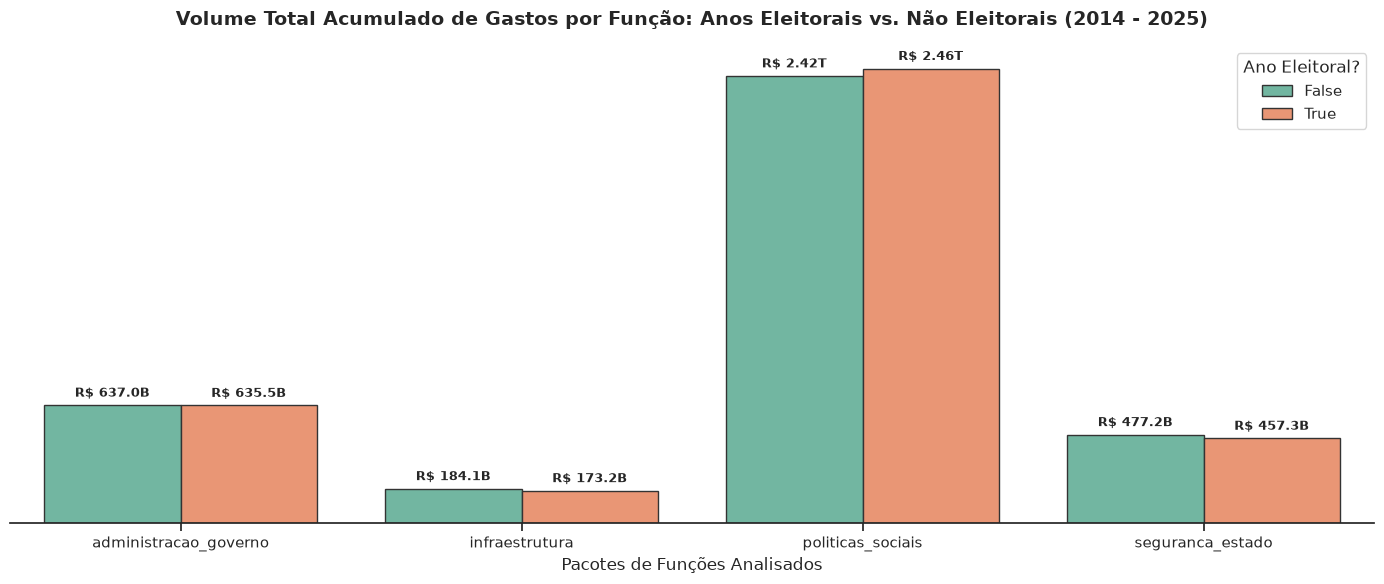

In [10]:
plt.figure(figsize=(14, 6))

ax_func1 = sns.barplot(
    data=df_func_eleicao, 
    x='pacote', 
    y='total_pago', 
    hue='fl_ano_eleitoral', 
    palette='Set2', # Cor diferente para diferenciar da Seção 1
    edgecolor='0.2'
)

plt.title('Volume Total Acumulado de Gastos por Função: Anos Eleitorais vs. Não Eleitorais (2014 - 2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Pacotes de Funções Analisados', fontsize=12)

# Limpeza minimalista do eixo Y
plt.ylabel('')
ax_func1.set_yticklabels([])
ax_func1.get_yaxis().set_visible(False)
plt.legend(title='Ano Eleitoral?', loc='upper right')

# Rótulos de dados
for container in ax_func1.containers:
    labels = []
    for v in container:
        height = v.get_height()
        if height >= 1e12:
            labels.append(f'R$ {height/1e12:.2f}T')
        elif height >= 1e9:
            labels.append(f'R$ {height/1e9:.1f}B')
        else:
            labels.append(f'R$ {height/1e6:.0f}M')
    ax_func1.bar_label(container, labels=labels, label_type='edge', fontsize=9, fontweight='bold', padding=4)

sns.despine(left=True)
plt.tight_layout()
plt.show()

### 💡 Hipótese 2.2: O tipo de eleição afeta a destinação dos recursos por função?
**Objetivo:** Analisar se o comportamento de gastos nas áreas finalísticas (Funções) difere quando o país passa por eleições municipais comparado às eleições gerais. Isso ajuda a mapear se determinadas funções, como `politicas_sociais`, sofrem maior pressão orçamentária dependendo da esfera política em disputa.

In [11]:
df_func_tipo_eleicao = con.sql("""
    SELECT 
        pacote,
        tipo_eleicao,
        SUM(valor_pago) as total_pago
    FROM ouro.despesas_funcional_programatica
    WHERE tipo_eleicao IS NOT NULL 
      AND tipo_eleicao != 'Não aplicável'
      AND ano < 2026
    GROUP BY pacote, tipo_eleicao
    ORDER BY pacote, total_pago DESC
""").df()

print("--- Gastos Funcionais por Tipo de Eleição ---")
display(df_func_tipo_eleicao)

--- Gastos Funcionais por Tipo de Eleição ---


,pacote,tipo_eleicao,total_pago
0,administracao_governo,municipal,3.286507e+11
1,administracao_governo,geral,3.068891e+11
2,infraestrutura,municipal,8.961852e+10
3,infraestrutura,geral,8.360279e+10
4,politicas_sociais,municipal,1.501434e+12
5,politicas_sociais,geral,9.616367e+11
6,seguranca_estado,municipal,2.499780e+11
7,seguranca_estado,geral,2.073501e+11


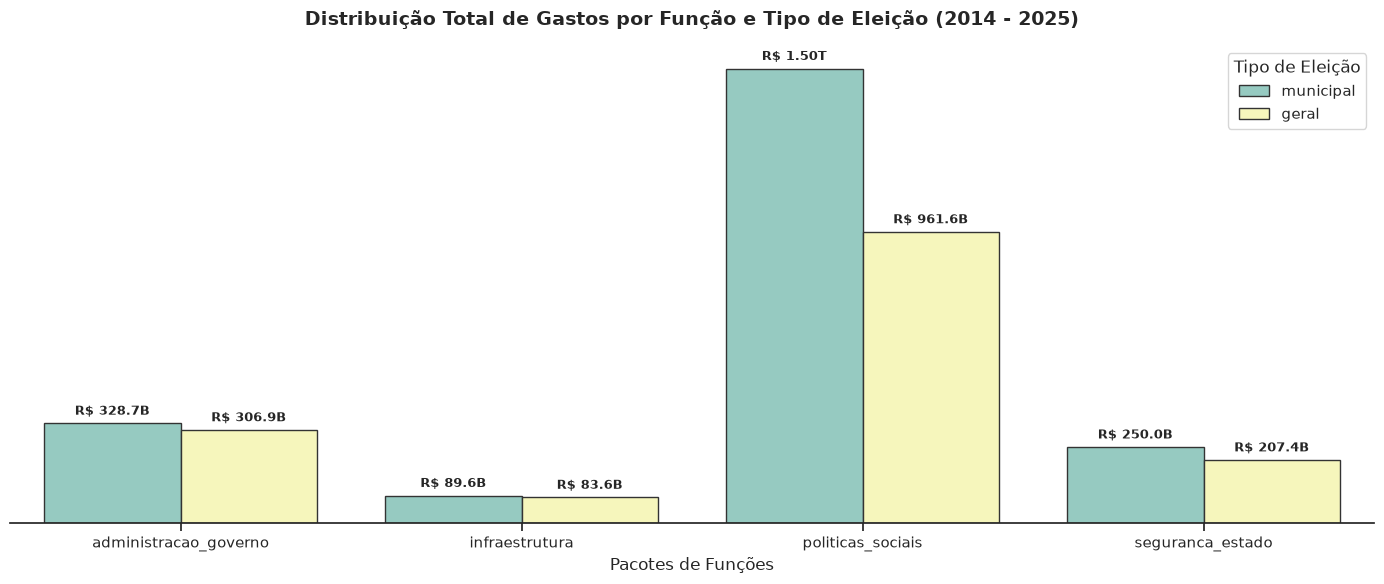

In [12]:
plt.figure(figsize=(14, 6))

ax_func2 = sns.barplot(
    data=df_func_tipo_eleicao, 
    x='pacote', 
    y='total_pago', 
    hue='tipo_eleicao', 
    palette='Set3', # Tom pastel diferenciado para manter a identidade visual limpa
    edgecolor='0.2'
)

plt.title('Distribuição Total de Gastos por Função e Tipo de Eleição (2014 - 2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Pacotes de Funções', fontsize=12)

# Limpeza minimalista padrão para esconder escala matemática e dar leveza ao layout
plt.ylabel('')
ax_func2.set_yticklabels([])
ax_func2.get_yaxis().set_visible(False)
plt.legend(title='Tipo de Eleição', loc='upper right')

# Inclusão dos rótulos de dados flutuantes inteligentes
for container in ax_func2.containers:
    labels = []
    for v in container:
        height = v.get_height()
        if height >= 1e12:
            labels.append(f'R$ {height/1e12:.2f}T')
        elif height >= 1e9:
            labels.append(f'R$ {height/1e9:.1f}B')
        else:
            labels.append(f'R$ {height/1e6:.0f}M')
    ax_func2.bar_label(container, labels=labels, label_type='edge', fontsize=9, fontweight='bold', padding=4)

sns.despine(left=True)
plt.tight_layout()
plt.show()

---

### 💡 Hipótese 3.2: Governos diferentes priorizaram funções (áreas) diferentes?
**Objetivo:** Esta é uma das respostas mais ricas do projeto. Queremos descobrir se um determinado `governo` focou o orçamento em `politicas_sociais` enquanto outro focou em `seguranca_estado` ou `administracao_governo`.

In [13]:
df_func_governo = con.sql("""
    SELECT 
        governo,
        pacote,
        SUM(valor_pago) as total_pago
    FROM ouro.despesas_funcional_programatica
    WHERE ano < 2026
    GROUP BY governo, pacote
    ORDER BY governo, total_pago DESC
""").df()

print("--- Distribuição de Funções por Gestão de Governo ---")
display(df_func_governo)

--- Distribuição de Funções por Gestão de Governo ---


,governo,pacote,total_pago
0,Bolsonaro,politicas_sociais,1.770753e+12
1,Bolsonaro,administracao_governo,4.079457e+11
2,Bolsonaro,seguranca_estado,3.431326e+11
3,Bolsonaro,infraestrutura,1.024142e+11
4,Dilma 1,politicas_sociais,2.340791e+11
5,Dilma 1,administracao_governo,9.082578e+10
6,Dilma 1,seguranca_estado,4.146856e+10
7,Dilma 1,infraestrutura,2.354856e+10
8,Dilma 2,politicas_sociais,4.971028e+11
9,Dilma 2,administracao_governo,1.795531e+11


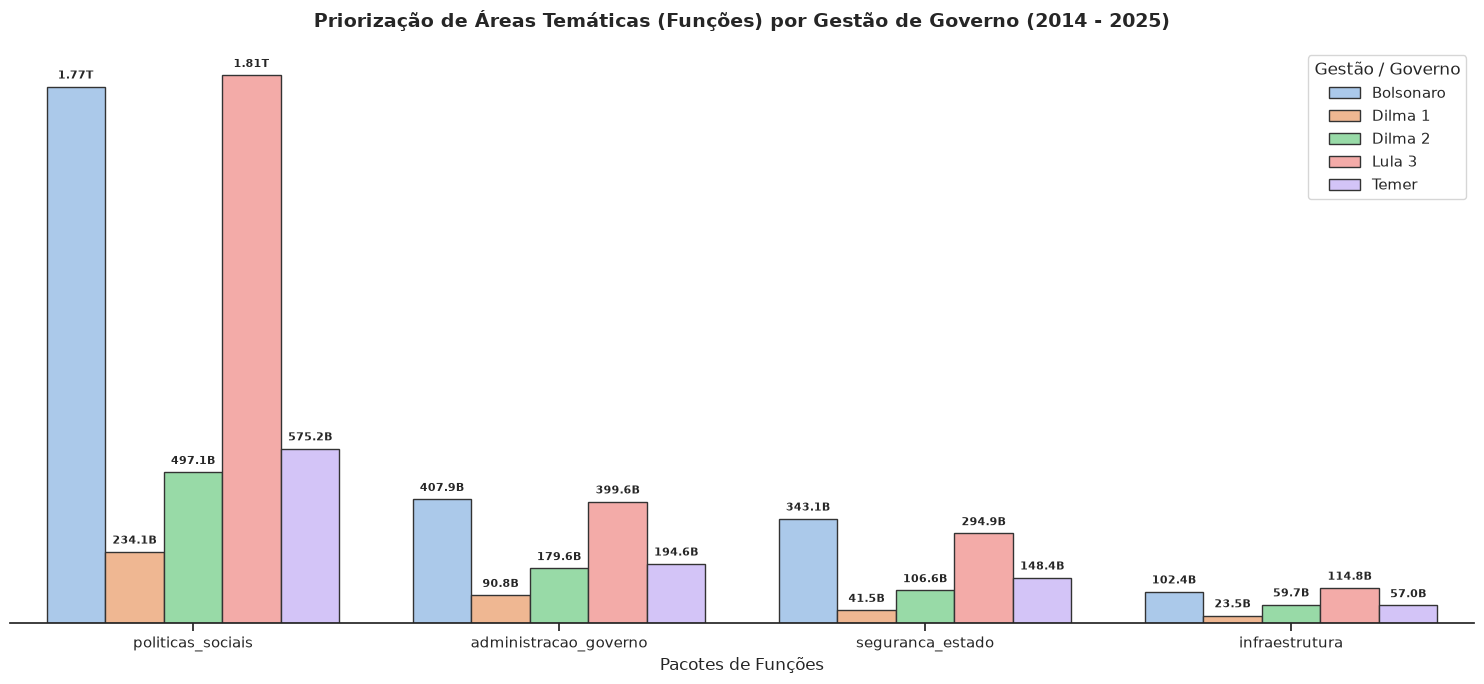

In [14]:
plt.figure(figsize=(15, 7))

ax_func3 = sns.barplot(
    data=df_func_governo, 
    x='pacote', 
    y='total_pago', 
    hue='governo', 
    palette='pastel',
    edgecolor='0.2'
)

plt.title('Priorização de Áreas Temáticas (Funções) por Gestão de Governo (2014 - 2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Pacotes de Funções', fontsize=12)

# Limpeza minimalista do eixo Y
plt.ylabel('')
ax_func3.set_yticklabels([])
ax_func3.get_yaxis().set_visible(False)
plt.legend(title='Gestão / Governo', loc='upper right')

# Rótulos de dados
for container in ax_func3.containers:
    labels = []
    for v in container:
        height = v.get_height()
        if height >= 1e12:
            labels.append(f'{height/1e12:.2f}T')
        elif height >= 1e9:
            labels.append(f'{height/1e9:.1f}B')
        else:
            labels.append(f'{height/1e6:.0f}M')
    ax_func3.bar_label(container, labels=labels, label_type='edge', fontsize=8, fontweight='bold', padding=4)

sns.despine(left=True)
plt.tight_layout()
plt.show()

# 🏁 Conclusão da Etapa de Análise de Despesas (Insights & Hipóteses)

Após o cruzamento analítico das tabelas da camada `ouro` com os atributos de contexto político e temporal entre os anos de 2014 e 2025, validamos e quantificamos os comportamentos orçamentários sob as óticas de Órgãos (`despesas_por_orgao`) e Funções (`despesas_funcional_programatica`).

---

### 1. Dinâmica dos Ciclos Eleitorais (Hipóteses 1 e 1.2)
* **Estabilidade Temporal Acumulada:** Diferente do senso comum, o volume total acumulado gasto pela máquina pública não sofre explosões em anos de eleição (`True`) se comparado aos anos regulares (`False`). O comportamento mostra-se marginalmente menor ou estável nos períodos eleitorais (ex: `coordenacao_politica` acumulando R$ 11,06T em anos não eleitorais vs. R$ 10,42T em anos eleitorais).
* **Rigidez de Destinação:** Na ótica finalística (Funções), o padrão se repete. O macro-bloco de `politicas_sociais` manteve uma execução praticamente idêntica entre os dois cenários, somando R$ 2,43T (anos regulares) vs. R$ 2,46T (anos eleitorais), o que indica que o fluxo de repasses das áreas finalísticas é blindado por regras de vinculação constitucional.

### 2. Centralização de Esferas Políticas (Hipóteses 2 e 2.2)
* **Pressão Orçamentária em Eleições Municipais:** Observa-se que anos de eleições **municipais** registram volumes de gastos superiores aos anos de eleições **gerais** em pacotes estratégicos. O pacote `coordenacao_politica` saltou para R$ 5,62T em contexto municipal contra R$ 4,80T no geral. O pacote `nucleo_eleitoral` seguiu a mesma tendência (R$ 3,61T municipal vs. R$ 2,76T geral).
* **Impacto na Ponta (Áreas-Fim):** Esse fenômeno é explicado pela distribuição funcional. Em anos de eleições municipais, o investimento em `politicas_sociais` atinge seu ápice histórico acumulado (R$ 1,50T) em comparação aos anos de eleições gerais (R$ 961,6B). Isso sinaliza uma forte indução e descentralização de recursos federais direcionados a municípios para o fortalecimento de programas sociais na base eleitoral local.

### 3. Priorização de Diretrizes por Gestão (Hipóteses 3 e 3.2)
* **Análise de Escopo por Governo:** O alinhamento ideológico e as prioridades programáticas ficam nítidos no gráfico comparativo de gestões. Os governos de maior duração temporal da série ou com períodos de teto orçamentário expandido (como as gestões de `Bolsonaro` e `Lula 3`) lideram em termos de volumes absolutos acumulados em pacotes como `coordenacao_politica` e `nucleo_eleitoral`.
* **A Transição Temática Real:** Sob o prisma funcional, a alocação de recursos em `politicas_sociais` mostra as gestões `Bolsonaro` (R$ 1,77T) e `Lula 3` (R$ 1,81T) muito próximas em volume bruto acumulado. Em contrapartida, as análises de pacotes menores como `infraestrutura` expõem os limites e as amarras orçamentárias históricas, com variações muito mais modestas entre os diferentes mandatos analisados.

---

### 🚀 Prontidão para o Notebook 3 (Machine Learning)

Os resultados do Notebook 2 comprovam que **os atributos políticos possuem correlação direta com a variação e distribuição do orçamento público**. Concluímos que:
1. As colunas `tipo_eleicao`, `governo` e `pacote` atuam como fortes indexadores de tendência do gasto e devem ser tratadas como *features* categóricas determinantes nos modelos.
2. A previsibilidade da série histórica se beneficiará da quebra por segmentação de pacotes, uma vez que a dinâmica de `politicas_sociais` e `coordenacao_politica` responde a estímulos temporais completamente distintos de `infraestrutura`.

*Análise exploratória avançada e cruzamentos analíticos validados. O ecossistema está pronto para a modelagem preditiva no **Notebook 3: Machine Learning**.*